# Introduccion Clustering

# Importacion de librerias

In [56]:
import warnings
warnings.filterwarnings("ignore")

In [57]:
%pip install --upgrade scipy statsmodels scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error

# Librerias para clustering
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster, cophenet
from scipy.spatial.distance import pdist, squareform


Note: you may need to restart the kernel to use updated packages.


---

# EDA

In [58]:
# Load wine.data and convert to CSV with proper column names
column_names = ['Alcohol', 'Malic acid', 'Ash', 'Alcalinity of ash', 'Magnesium', 
                'Total phenols', 'Flavanoids', 'Nonflavanoid phenols', 'Proanthocyanins',
                'Color intensity', 'Hue', 'OD280/OD315 of diluted wines', 'Proline']

df_wine = pd.read_csv('../../../../Archivos-Analisis/files-practica-m45/wine.data', names=column_names)
df_wine.to_csv('../../../../Archivos-Analisis/files-practica-m45/wine.csv', index=False)
df_wine.head()

,Alcohol,Malic acid,Ash,Alcalinity of ash,Magnesium,Total phenols,Flavanoids,Nonflavanoid phenols,Proanthocyanins,Color intensity,Hue,OD280/OD315 of diluted wines,Proline
1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [59]:
df_wine.shape

(178, 13)

In [60]:
df_wine.dtypes

Alcohol                         float64
Malic acid                      float64
Ash                             float64
Alcalinity of ash               float64
Magnesium                         int64
Total phenols                   float64
Flavanoids                      float64
Nonflavanoid phenols            float64
Proanthocyanins                 float64
Color intensity                 float64
Hue                             float64
OD280/OD315 of diluted wines    float64
Proline                           int64
dtype: object

In [61]:
df_wine.info()

<class 'pandas.core.frame.DataFrame'>
Index: 178 entries, 1 to 3
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Alcohol                       178 non-null    float64
 1   Malic acid                    178 non-null    float64
 2   Ash                           178 non-null    float64
 3   Alcalinity of ash             178 non-null    float64
 4   Magnesium                     178 non-null    int64  
 5   Total phenols                 178 non-null    float64
 6   Flavanoids                    178 non-null    float64
 7   Nonflavanoid phenols          178 non-null    float64
 8   Proanthocyanins               178 non-null    float64
 9   Color intensity               178 non-null    float64
 10  Hue                           178 non-null    float64
 11  OD280/OD315 of diluted wines  178 non-null    float64
 12  Proline                       178 non-null    int64  
dtypes: float64(1

In [62]:
df_wine.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Alcohol,178.0,13.00,0.81,11.03,12.36,13.05,13.68,14.83
Malic acid,178.0,2.34,1.12,0.74,1.60,1.87,3.08,5.80
Ash,178.0,2.37,0.27,1.36,2.21,2.36,2.56,3.23
Alcalinity of ash,178.0,19.49,3.34,10.60,17.20,19.50,21.50,30.00
Magnesium,178.0,99.74,14.28,70.00,88.00,98.00,107.00,162.00
Total phenols,178.0,2.30,0.63,0.98,1.74,2.36,2.80,3.88
Flavanoids,178.0,2.03,1.00,0.34,1.20,2.13,2.88,5.08
Nonflavanoid phenols,178.0,0.36,0.12,0.13,0.27,0.34,0.44,0.66
Proanthocyanins,178.0,1.59,0.57,0.41,1.25,1.56,1.95,3.58
Color intensity,178.0,5.06,2.32,1.28,3.22,4.69,6.20,13.00


In [63]:
df_wine.isnull().sum()

Alcohol                         0
Malic acid                      0
Ash                             0
Alcalinity of ash               0
Magnesium                       0
Total phenols                   0
Flavanoids                      0
Nonflavanoid phenols            0
Proanthocyanins                 0
Color intensity                 0
Hue                             0
OD280/OD315 of diluted wines    0
Proline                         0
dtype: int64

In [64]:
df_wine.nunique().sort_values()

Nonflavanoid phenols             39
Magnesium                        53
Alcalinity of ash                63
Hue                              78
Ash                              79
Total phenols                    97
Proanthocyanins                 101
Proline                         121
OD280/OD315 of diluted wines    122
Alcohol                         126
Flavanoids                      132
Color intensity                 132
Malic acid                      133
dtype: int64

In [65]:
# Cuenta el numero de 0 por cada columna
# Esto se hizo por que en algunas de ellas el minimo es cero 
df_wine[df_wine==0].count() / df_wine.count()

Alcohol                         0.0
Malic acid                      0.0
Ash                             0.0
Alcalinity of ash               0.0
Magnesium                       0.0
Total phenols                   0.0
Flavanoids                      0.0
Nonflavanoid phenols            0.0
Proanthocyanins                 0.0
Color intensity                 0.0
Hue                             0.0
OD280/OD315 of diluted wines    0.0
Proline                         0.0
dtype: float64

In [66]:
# Buscamos duplcados
df_wine.duplicated()

# Numero de duplicados
df_wine.duplicated().sum()

np.int64(0)

Insights
- No existen columnas con valores de 0
- Tampoco se tienen columnas con indicadores tipo ID, por lo que ne deben eliminar
- Ademas de que todas las columnas cuentan con multiples datos unicos, por lo que tampoco se deben de eliminar en caso de que llegaran a tener 1 unico valor
- No se encontraron valores nulos en ninguna de las columnas por lo que no se requerira instanciar informacion
- De igual forma no se encontraron valores duplicados

---

# Analisis Bivariado y Correlacion

## Correlacion

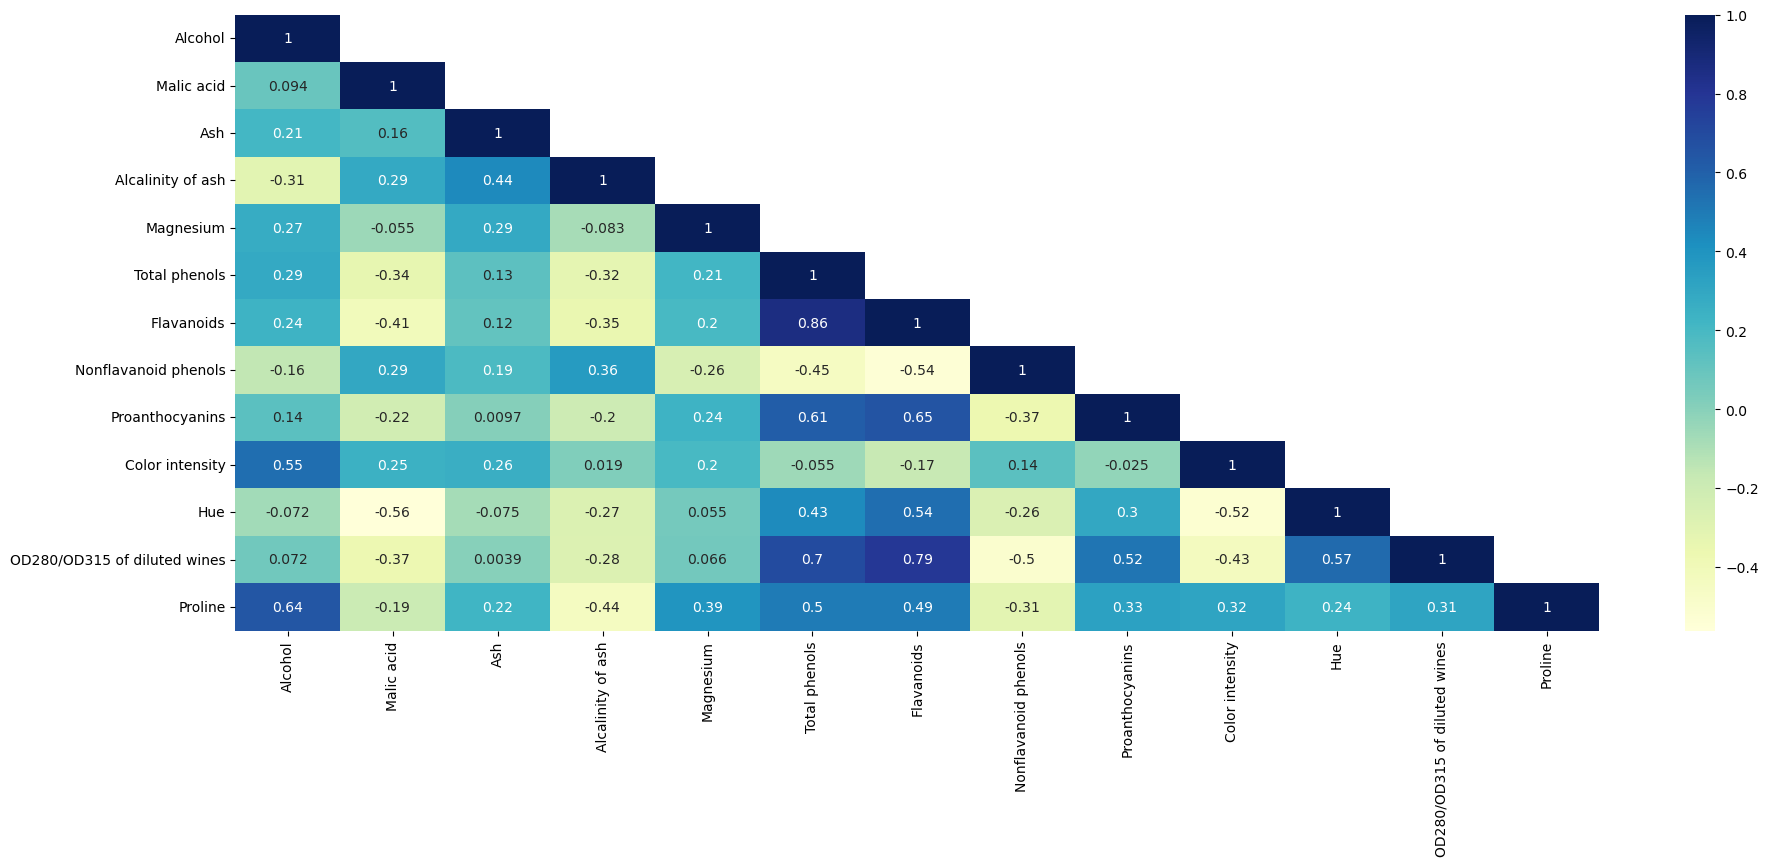

In [67]:
plt.figure(figsize=(22,8))
corr_df = corr = df_wine.corr(method='pearson')
df_lt = corr.where(np.tril(np.ones(corr_df.shape)).astype(bool))
hmap = sns.heatmap(df_lt, cmap='YlGnBu', annot=True)

Insighta
 - Se tiene una correlacion alta entre: Flavanoids y OD280, y Flavanoids y Total_Phenols, que si bien es alta, no superan el 0.9
 - Se podria estudiar si es que existen potenciales relaciones adicionales entre ellos pero se ha definido el no hacerlo
 - Por el momento ninguna columan se elimina

In [68]:
# Gradico de Distribucion por columnas numericas
numerics = ['int16', 'int32', 'int64', 'float16', 'float32', 'float64']
df_wine.select_dtypes(include=numerics).sample(5)

,Alcohol,Malic acid,Ash,Alcalinity of ash,Magnesium,Total phenols,Flavanoids,Nonflavanoid phenols,Proanthocyanins,Color intensity,Hue,OD280/OD315 of diluted wines,Proline
2,12.60,1.34,1.90,18.5,88,1.45,1.36,0.29,1.35,2.45,1.04,2.77,562
3,13.36,2.56,2.35,20.0,89,1.40,0.50,0.37,0.64,5.60,0.70,2.47,780
2,12.43,1.53,2.29,21.5,86,2.74,3.15,0.39,1.77,3.94,0.69,2.84,352
1,14.06,1.63,2.28,16.0,126,3.00,3.17,0.24,2.10,5.65,1.09,3.71,780
3,13.71,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740


In [69]:
cols_num = df_wine.columns[[np.issubdtype(dt, np.number) for dt in df_wine.dtypes]]
cols_num

Index(['Alcohol', 'Malic acid', 'Ash', 'Alcalinity of ash', 'Magnesium',
       'Total phenols', 'Flavanoids', 'Nonflavanoid phenols',
       'Proanthocyanins', 'Color intensity', 'Hue',
       'OD280/OD315 of diluted wines', 'Proline'],
      dtype='object')

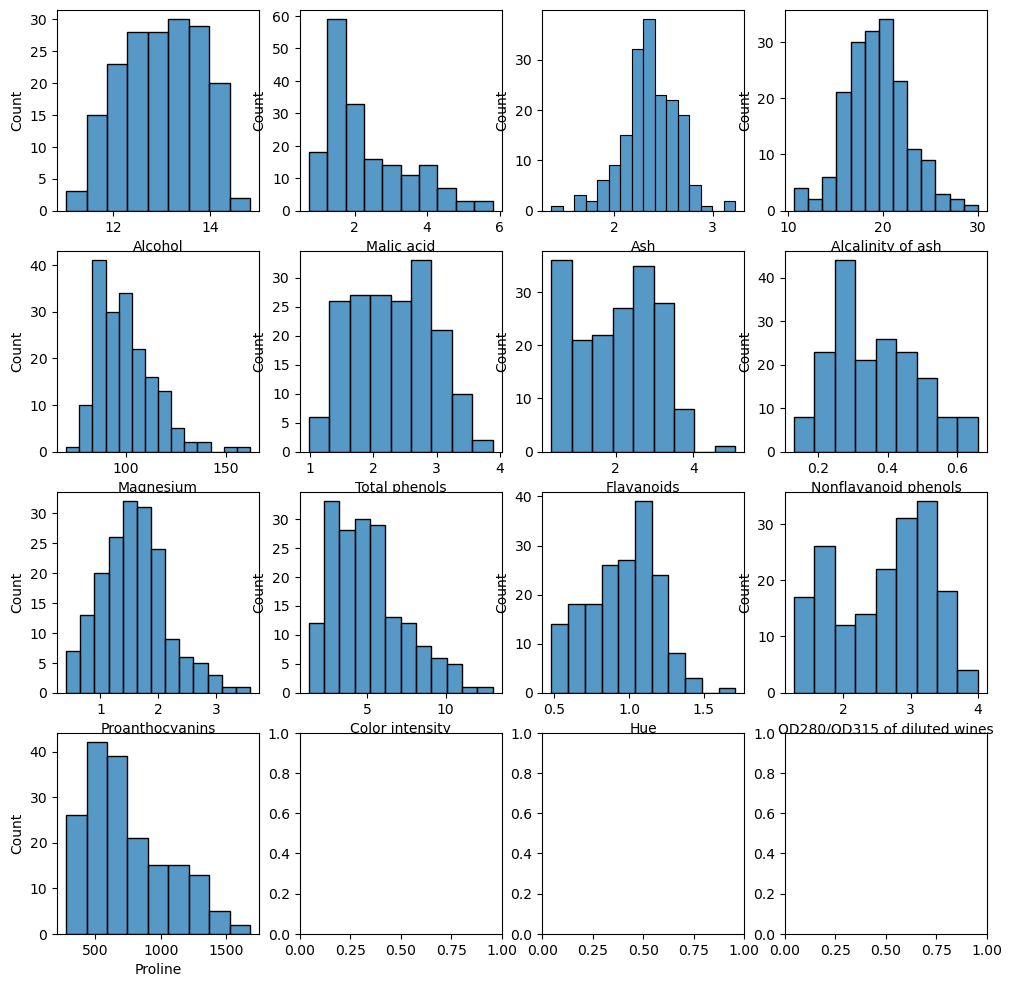

In [70]:
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(12,12))
for i, column in enumerate(cols_num):
    sns.histplot(df_wine[column], ax=axes[i//4, i%4], kde=False)

Text(0.5, 1.0, 'Boxplot de variables')

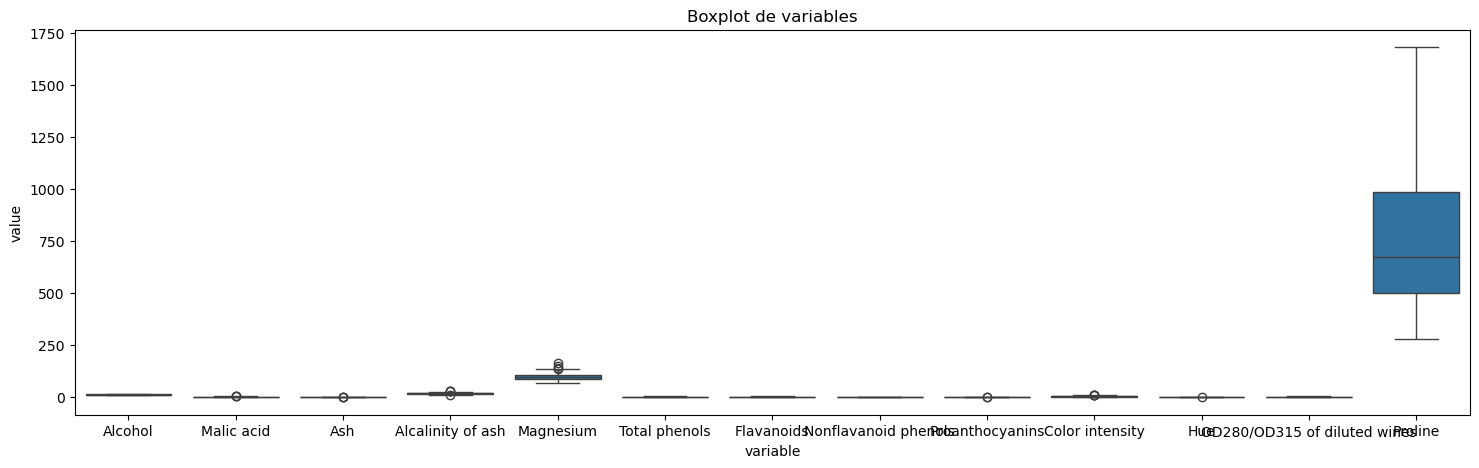

In [71]:
# Buscamos rangos en las variables y potenciales outliers
plt.figure(figsize=(18, 5))
sns.boxplot(x='variable', y='value', data=pd.melt(df_wine[cols_num])).set_title('Boxplot de variables')

Insights
- No se ve ninguna columna con outliers
- El rango de la columna de Proline deberia normalizarse
- Las demas variables no requeieren, un inicio, ninguna transformacion

---

## Bivariado

---

# Feature Engineering

## Transfomacion

In [72]:
df2 = df_wine.copy()

In [73]:
# Para el labeling final
df3 = df_wine.copy()

In [74]:
# Escalamiento zscore
from scipy.stats import zscore
df2 = df2.apply(zscore)

In [75]:
df2.describe().T

,count,mean,std,min,25%,50%,75%,max
Alcohol,178.0,-8.382808e-16,1.002821,-2.434235,-0.788245,0.061000,0.836129,2.259772
Malic acid,178.0,-1.197544e-16,1.002821,-1.432983,-0.658749,-0.423112,0.669793,3.109192
Ash,178.0,-8.370333e-16,1.002821,-3.679162,-0.572122,-0.023821,0.698109,3.156325
Alcalinity of ash,178.0,-3.991813e-17,1.002821,-2.671018,-0.689137,0.001518,0.602088,3.154511
Magnesium,178.0,-3.991813e-17,1.002821,-2.088255,-0.824415,-0.122282,0.509638,4.371372
Total phenols,178.0,0.000000e+00,1.002821,-2.107246,-0.885468,0.095960,0.808997,2.539515
Flavanoids,178.0,-3.991813e-16,1.002821,-1.695971,-0.827539,0.106150,0.849085,3.062832
Nonflavanoid phenols,178.0,3.592632e-16,1.002821,-1.868234,-0.740141,-0.176095,0.609541,2.402403
Proanthocyanins,178.0,-1.197544e-16,1.002821,-2.069034,-0.597284,-0.062898,0.629175,3.485073
Color intensity,178.0,2.494883e-17,1.002821,-1.634288,-0.795103,-0.159225,0.493956,3.435432


---

# Modelo de Clustering K-Means

Text(0.5, 1.0, 'Resultado KMeans')

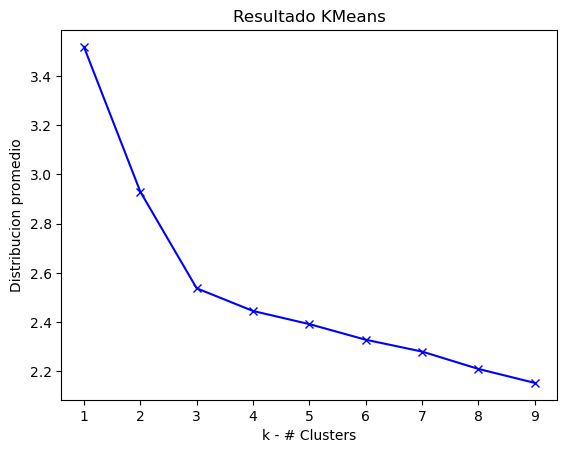

In [76]:
# Buscando el optimo numero de clusters 
from scipy.spatial.distance import cdist
clusters = range (1, 10)
meanDistributions = []

for k in clusters:
    model = KMeans(n_clusters = k)
    model.fit(df2)
    prediction = model.predict(df2)

    meanDistributions.append(sum(np.min(cdist(df2, model.cluster_centers_, 'euclidean'), axis=1)) / df2.shape[0])

plt.plot(clusters, meanDistributions, 'bx-')
plt.xlabel('k - # Clusters')
plt.ylabel('Distribucion promedio')
plt.title('Resultado KMeans')

Insights
- Por inspeccion visual, un numero de 3 clusters parece el indicado, y donde se forma el 'Codo' en el grafico
- Se hizo un analisis entre 1 a 9 clusters

In [77]:
# Se genera el numero de clusters = 3
# El parametro n_init significa que se probara con 15 diferentes inicializaciones y se tomaran las mejores
kmeans = KMeans(n_clusters= 3, n_init = 15, random_state=1)
kmeans.fit(df2)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",15
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",1
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [78]:
centroides = kmeans.cluster_centers_
centroides

array([[ 0.83523208, -0.30380968,  0.36470604, -0.61019129,  0.5775868 ,
         0.88523736,  0.97781956, -0.56208965,  0.58028658,  0.17106348,
         0.47398365,  0.77924711,  1.12518529],
       [ 0.16490746,  0.87154706,  0.18689833,  0.52436746, -0.07547277,
        -0.97933029, -1.21524764,  0.72606354, -0.77970639,  0.94153874,
        -1.16478865, -1.29241163, -0.40708796],
       [-0.92607185, -0.39404154, -0.49451676,  0.17060184, -0.49171185,
        -0.07598265,  0.02081257, -0.03353357,  0.0582655 , -0.90191402,
         0.46180361,  0.27076419, -0.75384618]])

In [79]:
centroides_df = pd.DataFrame(centroides, columns = list(df2))
centroides_df

,Alcohol,Malic acid,Ash,Alcalinity of ash,Magnesium,Total phenols,Flavanoids,Nonflavanoid phenols,Proanthocyanins,Color intensity,Hue,OD280/OD315 of diluted wines,Proline
0,0.835232,-0.303810,0.364706,-0.610191,0.577587,0.885237,0.977820,-0.562090,0.580287,0.171063,0.473984,0.779247,1.125185
1,0.164907,0.871547,0.186898,0.524367,-0.075473,-0.979330,-1.215248,0.726064,-0.779706,0.941539,-1.164789,-1.292412,-0.407088
2,-0.926072,-0.394042,-0.494517,0.170602,-0.491712,-0.075983,0.020813,-0.033534,0.058266,-0.901914,0.461804,0.270764,-0.753846


In [80]:
# Se genera un DF para los leabls de los clusters y se los convertimos en categorias
df_labels = pd.DataFrame(kmeans.labels_, columns = list(['labels']))
df_labels['labels'] = df_labels['labels'].astype('category')

In [81]:
# Hacemos la union
df_labeled = df3.join(df_labels)
df_labeled.sample(5)

,Alcohol,Malic acid,Ash,Alcalinity of ash,Magnesium,Total phenols,Flavanoids,Nonflavanoid phenols,Proanthocyanins,Color intensity,Hue,OD280/OD315 of diluted wines,Proline,labels
3,13.62,4.95,2.35,20.0,92,2.00,0.80,0.47,1.02,4.40,0.91,2.05,550,0
3,12.87,4.61,2.48,21.5,86,1.70,0.65,0.47,0.86,7.65,0.54,1.86,625,0
1,13.94,1.73,2.27,17.4,108,2.88,3.54,0.32,2.08,8.90,1.12,3.10,1260,0
1,13.75,1.73,2.41,16.0,89,2.60,2.76,0.29,1.81,5.60,1.15,2.90,1320,0
2,12.33,1.10,2.28,16.0,101,2.05,1.09,0.63,0.41,3.27,1.25,1.67,680,0


In [82]:
# Division de los clusters
# numero de registros con cada uno de los clusters
df_labeled['labels'].value_counts()

labels
0    178
1      0
2      0
Name: count, dtype: int64

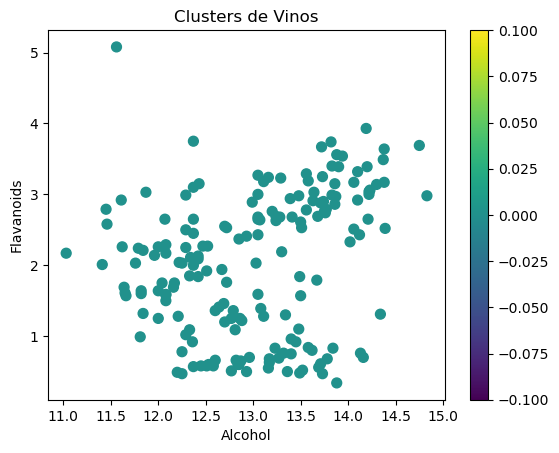

In [83]:
fig = plt.figure()
ax = fig.add_subplot(111)
scatter = ax.scatter(df_labeled['Alcohol'], df_labeled['Flavanoids'], c=df_labeled['labels'], s=50)
plt.xlabel('Alcohol')
plt.ylabel('Flavanoids')
plt.title('Clusters de Vinos')
plt.colorbar(scatter)

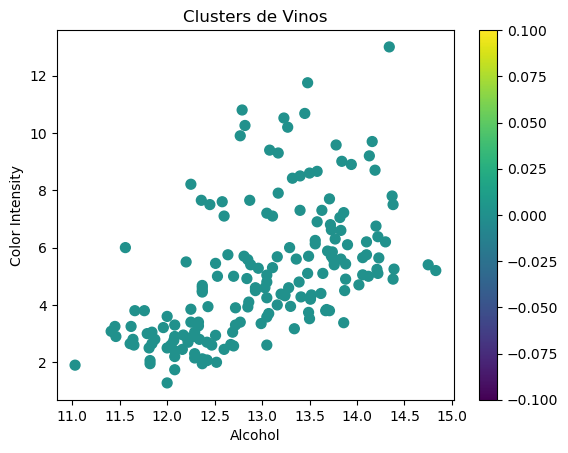

In [86]:
fig = plt.figure()
ax = fig.add_subplot(111)
scatter = ax.scatter(df_labeled['Alcohol'], df_labeled['Color intensity'], c=df_labeled['labels'], s=50)
plt.xlabel('Alcohol')
plt.ylabel('Color Intensity')
plt.title('Clusters de Vinos')
plt.colorbar(scatter)

---

# Bonus

## Hierarchical Cluster
- Se ejecuta un metodo llamado Clusterins Jerargico, que divide en un 'dendograma' a los datos
- Ademas se genera el concepto del indice cofenetico, para ver cual es el optimo numero de clusters

In [88]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster, cophenet
z = linkage(df2, 'average', metric='euclidean')
z.shape

(177, 4)

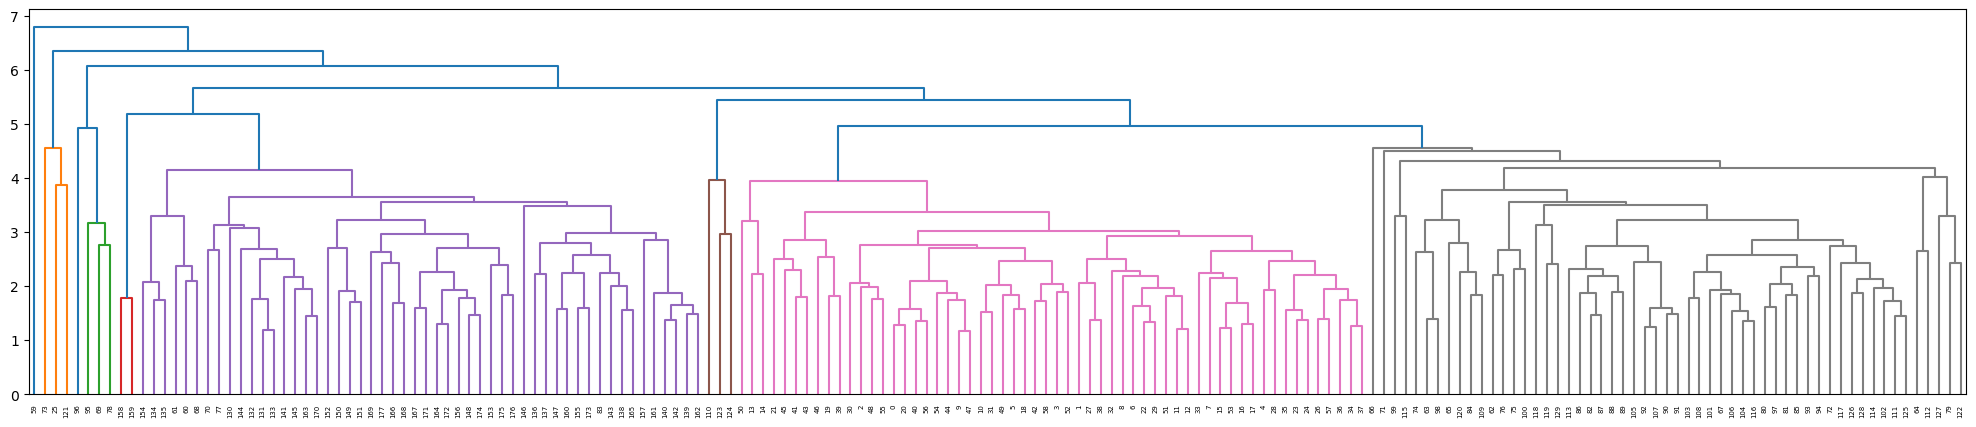

In [ ]:
# dendograma
plt.figure(figsize=(25, 5))
dendrogram(z)
plt.show()

In [ ]:
# Se  calcula el Coeficiente Cofenetico para calidar la caldiad del fit del dendograma con los pares de datos in ordenar
# El maximo de coeficiente es 1
c, coph_dists = cophenet(z, pdist(df2))
print('Coeficiente Cofenetico: ', format(c, '.4f'))

Coeficiente Cofenetico:  0.7591


---

## Silhouette Score
- Se calcula el Silhouette para el modelo
- Se prueba este score con un rango de 2 a 10, buscando el numero de clusters donde se produzca el peak del score
- El grafico muestra que tan consistente son los clusters

In [92]:
sil_df = pd.DataFrame({}, columns=['Model', 'n_clusters', 'score'], index=None)

In [96]:
from sklearn.metrics import silhouette_score

result = []

clusters = range(2, 10)

for n_clusters in clusters:
    clusters = KMeans(n_clusters=n_clusters, n_init=15, random_state=1)
    preds = clusters.fit_predict(df2)
    centers = clusters.cluster_centers_

    score = silhouette_score(df2, clusters.labels_, metric='euclidean')

    result.append({'Model':'KMeans', 'n_clusters': n_clusters, 'score': score})

sil_df = pd.DataFrame(result)
sil_df

,Model,n_clusters,score
0,KMeans,2,0.259317
1,KMeans,3,0.284859
2,KMeans,4,0.255582
3,KMeans,5,0.208990
4,KMeans,6,0.160704
5,KMeans,7,0.146843
6,KMeans,8,0.136318
7,KMeans,9,0.139393


Text(0.5, 1.0, 'Silhuette Score')

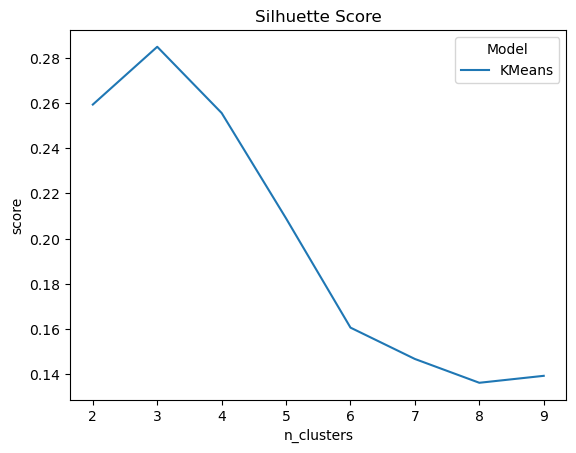

In [97]:
sns.lineplot(data=sil_df, x='n_clusters', y='score', hue='Model', style='Model', ci=None).set_title('Silhuette Score')

Insight
- Se confirma que k = 3, teine el mejor desempeño